In [2]:
import rioxarray as rxr

flood = rxr.open_rasterio("/home/server/pi/homes/queenl/projects/climate-risk-dc/data/JRC_flood/glofas_rp100_oregon.tif").squeeze()

print(flood.rio.bounds())

(-130.00458242778933, 40.00456666667576, -110.00624903922697, 50.00373333333333)


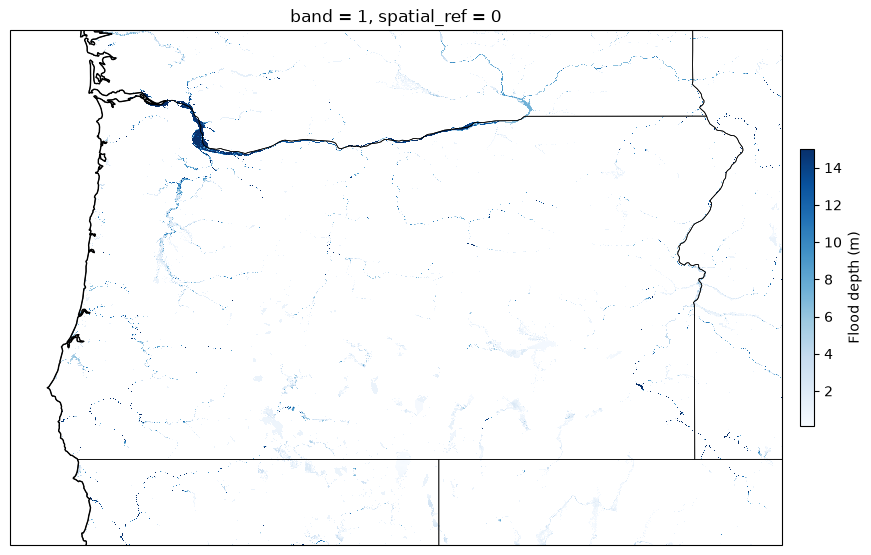

In [24]:
oregon = flood.sel( x=slice(-125, -116), y=slice(47, 41) ) 
oregon_plot = oregon.isel( x=slice(None, None, 2), y=slice(None, None, 2) ) 

fig, ax = plt.subplots(
    figsize=(12, 12),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

im = oregon_plot.where(oregon_plot > 0).plot(ax=ax, transform=ccrs.PlateCarree(), vmax=15, cmap="Blues", add_colorbar=False)

ax.coastlines(resolution="10m")
ax.add_feature(cfeature.STATES, linewidth=0.5)

cbar = plt.colorbar(
    im,
    ax=ax,
    shrink=0.3,
    pad=0.02,
)

cbar.set_label("Flood depth (m)")

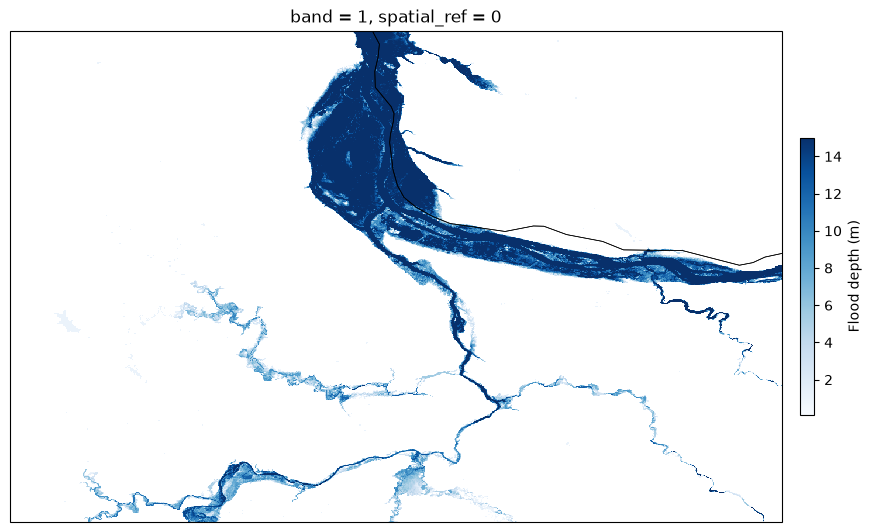

In [25]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Portland area (roughly)
portland = flood.sel(
    x=slice(-123.3, -122.2),
    y=slice(45.9, 45.2)   # y is descending
).where(lambda x: x > 0)

fig, ax = plt.subplots(
    figsize=(12, 12),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

im = portland.where(portland > 0).plot(ax=ax, transform=ccrs.PlateCarree(), vmax=15, cmap="Blues", add_colorbar=False)

ax.coastlines(resolution="10m")
ax.add_feature(cfeature.STATES, linewidth=0.5)

cbar = plt.colorbar(
    im,
    ax=ax,
    shrink=0.3,
    pad=0.02,
)

cbar.set_label("Flood depth (m)")